In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day4_cleaned.csv"
df = pd.read_csv(file_path)

In [4]:
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

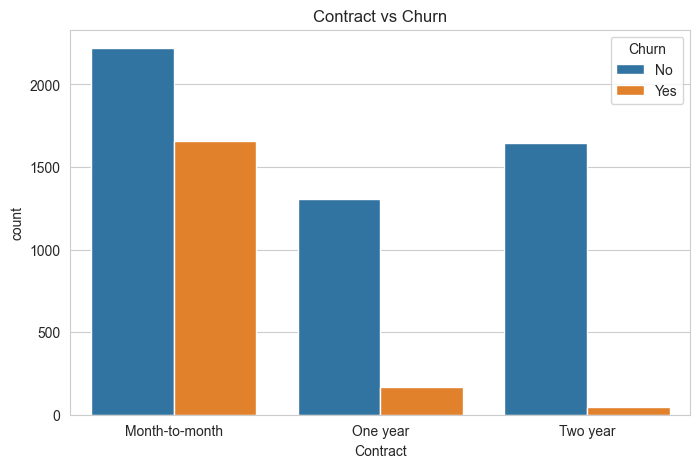

In [6]:
sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title("Contract vs Churn")
plt.show()

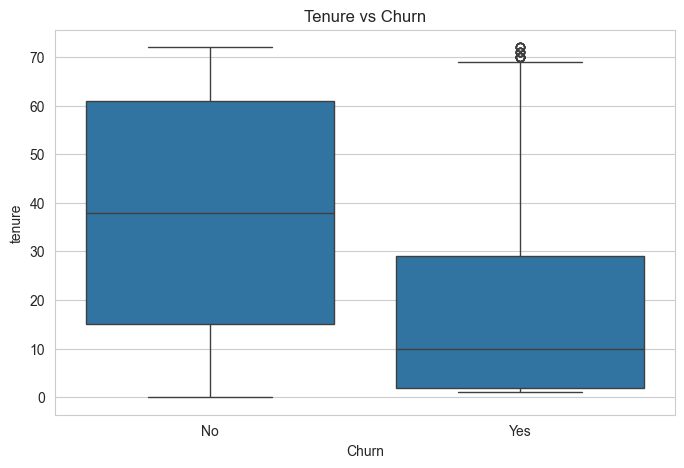

In [7]:
sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title("Tenure vs Churn")
plt.show()

In [8]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

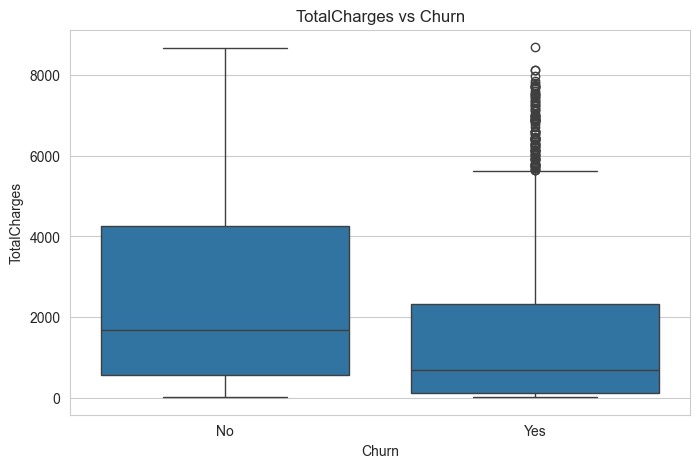

In [9]:
sns.boxplot(
    data=df,
    x='Churn',
    y='TotalCharges'
)

plt.title("TotalCharges vs Churn")
plt.show()

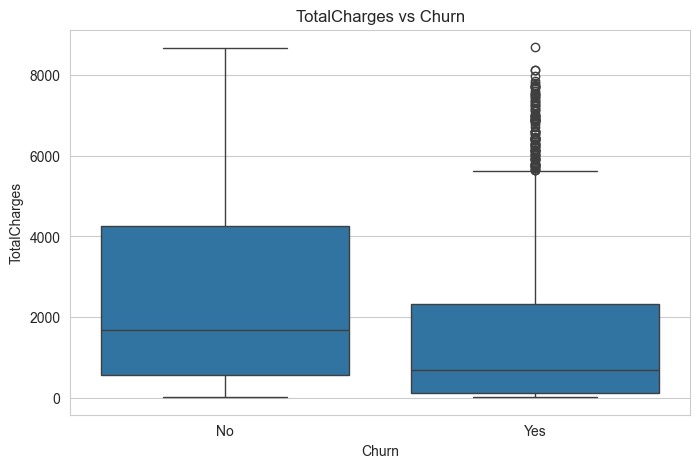

In [10]:
sns.boxplot(
    data=df,
    x='Churn',
    y='TotalCharges'
)

plt.title("TotalCharges vs Churn")
plt.show()

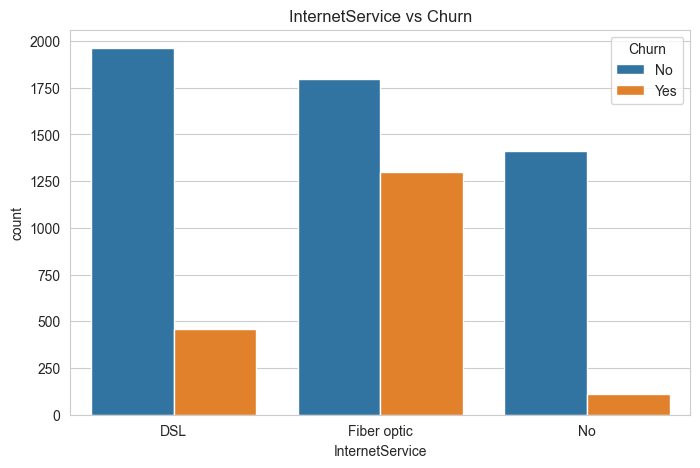

In [11]:
sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)

plt.title("InternetService vs Churn")
plt.show()

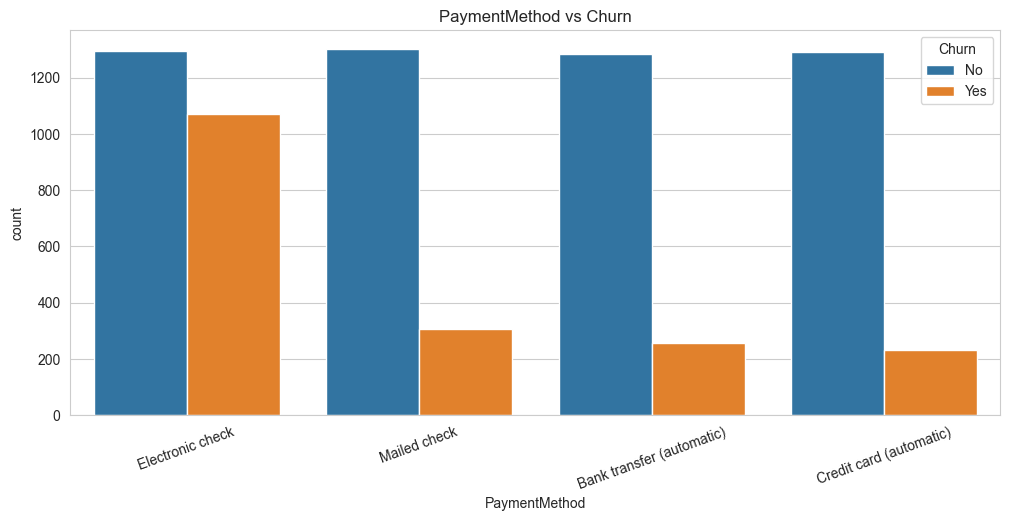

In [12]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.xticks(rotation=20)

plt.title("PaymentMethod vs Churn")
plt.show()

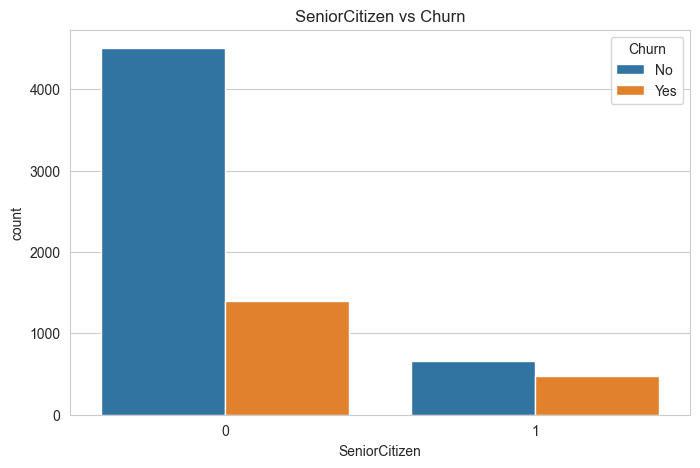

In [13]:
sns.countplot(
    data=df,
    x='SeniorCitizen',
    hue='Churn'
)

plt.title("SeniorCitizen vs Churn")
plt.show()

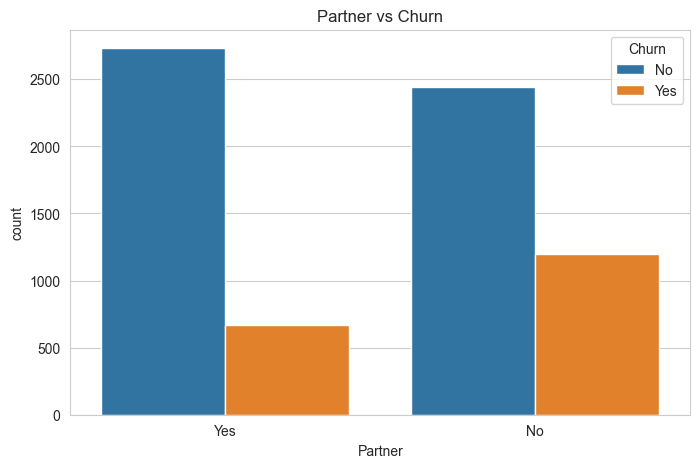

In [14]:
sns.countplot(
    data=df,
    x='Partner',
    hue='Churn'
)

plt.title("Partner vs Churn")
plt.show()

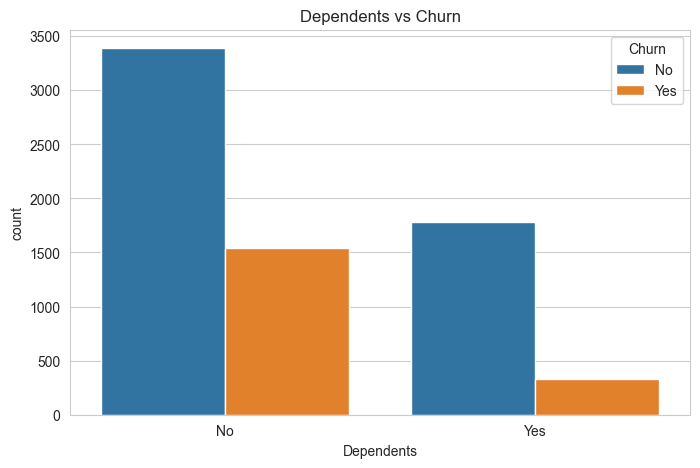

In [15]:
sns.countplot(
    data=df,
    x='Dependents',
    hue='Churn'
)

plt.title("Dependents vs Churn")
plt.show()

In [16]:
df.groupby('Churn')[
    ['MonthlyCharges', 'TotalCharges', 'tenure']
].mean()

,MonthlyCharges,TotalCharges,tenure
Churn,,,
No,61.265124,2555.344141,37.569965
Yes,74.441332,1531.796094,17.979133


In [17]:
df.groupby(
    ['Contract', 'Churn']
).size()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
dtype: int64

In [18]:
df.groupby('InternetService')[
    'MonthlyCharges'
].mean()

InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64

In [19]:
df.groupby('Contract').agg({
    'MonthlyCharges':['mean','min','max'],
    'tenure':['mean','max'],
    'customerID':'count'
})

MonthlyCharges                    tenure     customerID
                         mean    min     max       mean max      count
Contract                                                              
Month-to-month      66.398490  18.75  117.45  18.036645  72       3875
One year            65.048608  18.25  118.60  42.044807  72       1473
Two year            60.770413  18.40  118.75  56.735103  72       1695

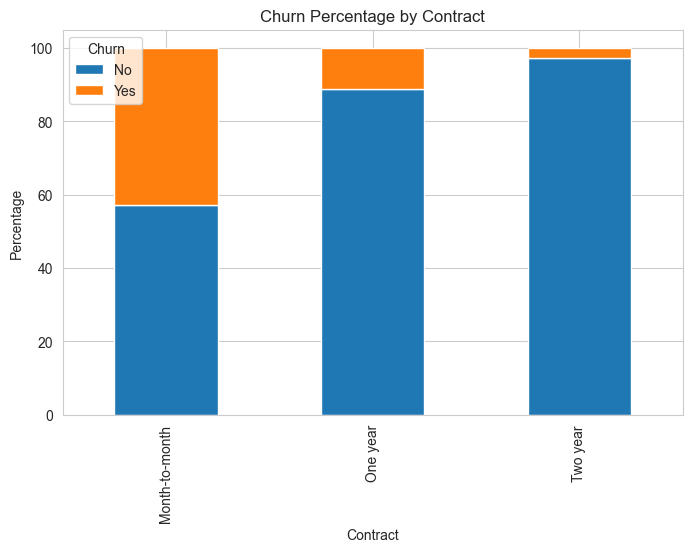

In [20]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn.plot(
    kind='bar',
    stacked=True
)

plt.title("Churn Percentage by Contract")
plt.ylabel("Percentage")
plt.show()

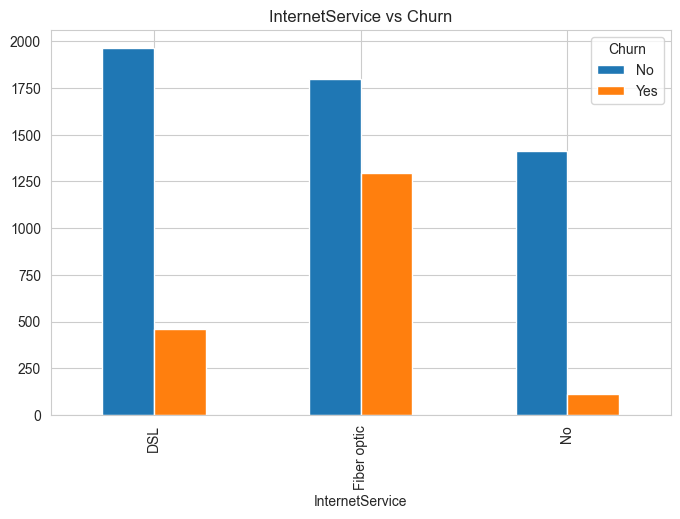

In [21]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn']
)

internet_churn.plot(
    kind='bar'
)

plt.title("InternetService vs Churn")
plt.show()

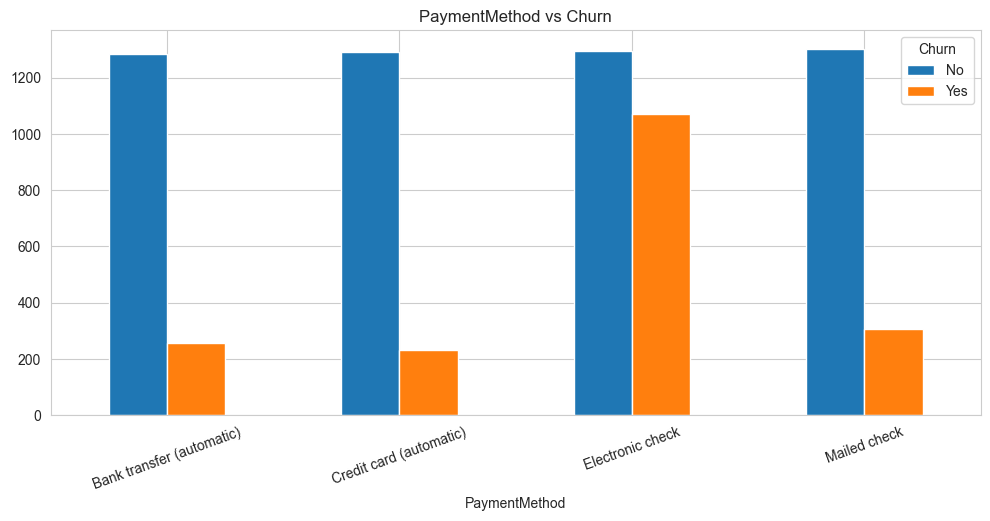

In [22]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn']
)

payment_churn.plot(
    kind='bar',
    figsize=(12,5)
)

plt.xticks(rotation=20)

plt.title("PaymentMethod vs Churn")
plt.show()

In [23]:
# DATASET SAVING
df.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day6_analysis.csv",
    index=False
)

# DAY 6 — Key Business Insights

- Customers with month-to-month contracts show higher churn.
- Customers with lower tenure are more likely to churn.
- Higher monthly charges are associated with increased churn risk.
- Fiber optic internet users show comparatively higher churn.
- Electronic check payment users exhibit higher churn behavior.
- Customers without partners or dependents churn more frequently.
- Long-term contract customers are more stable.
- Senior citizens show slightly elevated churn patterns.